# Erdős-Rényi & Barabási-Albert Graphs

In [7]:
import networkx as nx

G_real = nx.read_edgelist('out.dimacs10-netscience', comments='%', create_using=nx.Graph())

n = G_real.number_of_nodes()
m = G_real.number_of_edges()

print(f"Nodes: {n}, Edges: {m}")

max_edges = n * (n - 1) / 2
p = m / max_edges

print(f"Generating Erdos-Renyi Graph with n={n}, p={p}")
G_er = nx.erdos_renyi_graph(n, p)
print(f"Erdos-Renyi -> Nodes: {G_er.number_of_nodes()}, Edges: {G_er.number_of_edges()}")

m_ba = int(round(m / n))
m_ba = max(1, m_ba) 

print(f"Generating Barabasi-Albert Graph with n={n}, m={m_ba}...")
G_ba = nx.barabasi_albert_graph(n, m_ba)
print(f"Barabasi-Albert -> Nodes: {G_ba.number_of_nodes()}, Edges: {G_ba.number_of_edges()}")

nx.write_edgelist(G_er, 'ErdosRenyi.txt', data=False)
nx.write_edgelist(G_ba, 'BarabasiAlbert.txt', data=False)

Nodes: 1461, Edges: 2742
Generating Erdos-Renyi Graph with n=1461, p=0.0025709544035329526
Erdos-Renyi -> Nodes: 1461, Edges: 2695
Generating Barabasi-Albert Graph with n=1461, m=2...
Barabasi-Albert -> Nodes: 1461, Edges: 2918


### 1 & 2. Network Descriptions & Properties
Compute network properties: min/max/average degree, diameter, connected components and the size of the largest one, shortest paths, average clustering coefficient.

In [ ]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
warnings.filterwarnings('ignore')

graphs_info = [
    ("NetScience (Real Graph)", G_real), 
    ("Erdos-Renyi (Random Graph)", G_er), 
    ("Barabasi-Albert (Scale-Free Graph)", G_ba)
]

network_cache = {}

for name, G in graphs_info:
    print(f"\n{'='*50}\nAnalyzing properties for {name}\n{'='*50}")
    is_directed = G.is_directed()
    
    n = G.number_of_nodes()
    m = G.number_of_edges()
    print(f"Nodes (N): {n}, Edges (M): {m}")
    
    if name == "NetScience (Real Graph)":
        print("The graph represents a co-authorship network in the area of network science where nodes are authors and edges represent co-authorships. The graph is undirected.")
    print("\n")

    # Degrees
    degrees = [d for n, d in G.degree()]
    print(f"Min Degree: {np.min(degrees)}, Max Degree: {np.max(degrees)}, Avg Degree: {np.mean(degrees):.2f}")
    
    # Components, Diameter and Shortest Path
    print("\n--- Connectivity ---")
    ccs = list(nx.connected_components(G))
    largest_cc_nodes = max(ccs, key=len)
    gcc = G.subgraph(largest_cc_nodes).copy()
    print(f"Connected Components: {len(ccs)}")
    print(f"Largest Component Size: {len(largest_cc_nodes)}")
    try:
        print(f"Diameter (Largest Component): {nx.diameter(gcc)}")
        print(f"Avg Shortest Path (Largest Component): {nx.average_shortest_path_length(gcc):.4f}")
    except Exception as e:
        print("Could not compute diameter/shortest path efficiently:", e)

    # Clustering
    print("\n--- Clustering ---")
    print(f"Average Clustering Coefficient: {nx.average_clustering(G):.4f}")
    
    # Cache for later cells
    network_cache[name] = {
        'G': G,
        'ccs': ccs,
        'is_directed': is_directed
    }


Analyzing properties for NetScience (Real Graph)
Nodes (N): 1461, Edges (M): 2742
The graph represents a co-authorship network in the area of network science where nodes are authors and edges represent co-authorships. The graph is undirected.


Min Degree: 1, Max Degree: 34, Avg Degree: 3.75

--- Connectivity ---
Connected Components: 268
Largest Component Size: 379
Diameter (Largest Component): 17
Avg Shortest Path (Largest Component): 6.0419

--- Clustering ---
Average Clustering Coefficient: 0.6937

Analyzing properties for Erdos-Renyi (Random Graph)
Nodes (N): 1461, Edges (M): 2695


Min Degree: 0, Max Degree: 12, Avg Degree: 3.69

--- Connectivity ---
Connected Components: 35
Largest Component Size: 1422
Diameter (Largest Component): 12
Avg Shortest Path (Largest Component): 5.6831

--- Clustering ---
Average Clustering Coefficient: 0.0046

Analyzing properties for Barabasi-Albert (Scale-Free Graph)
Nodes (N): 1461, Edges (M): 2918


Min Degree: 2, Max Degree: 78, Avg Degree: 3.9

### 3. Visualization
Provide a visualization for the network (rendering the entire network structure to observe macro-properties instead of sampling).

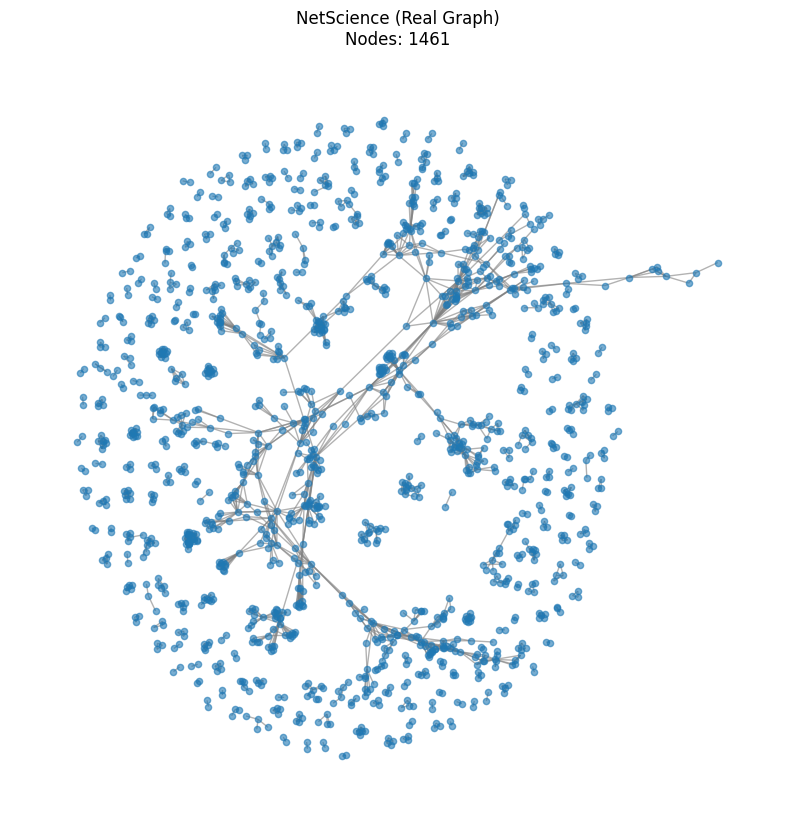

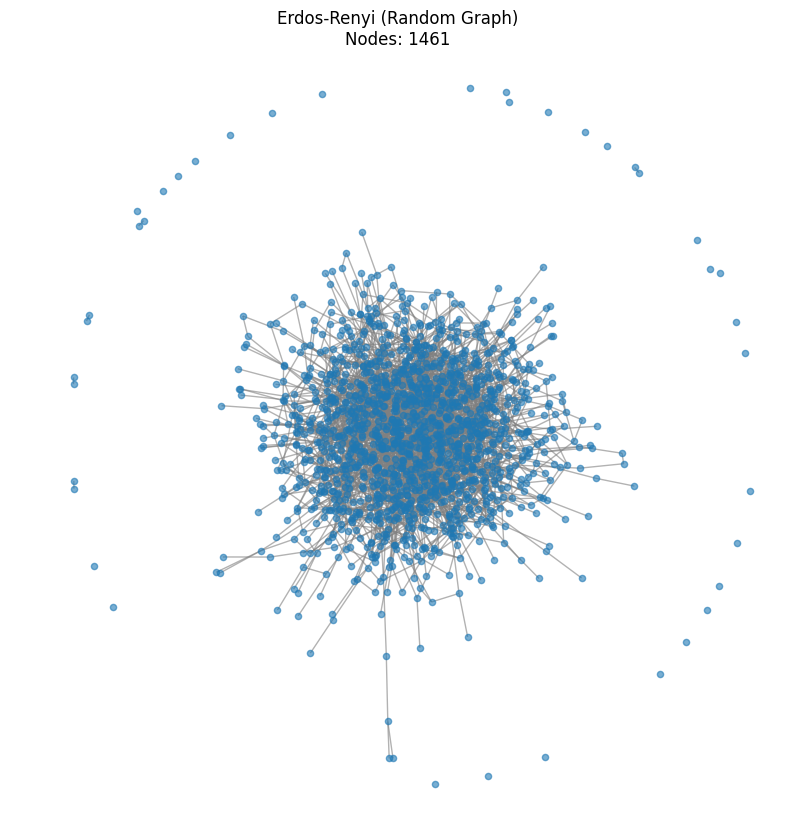

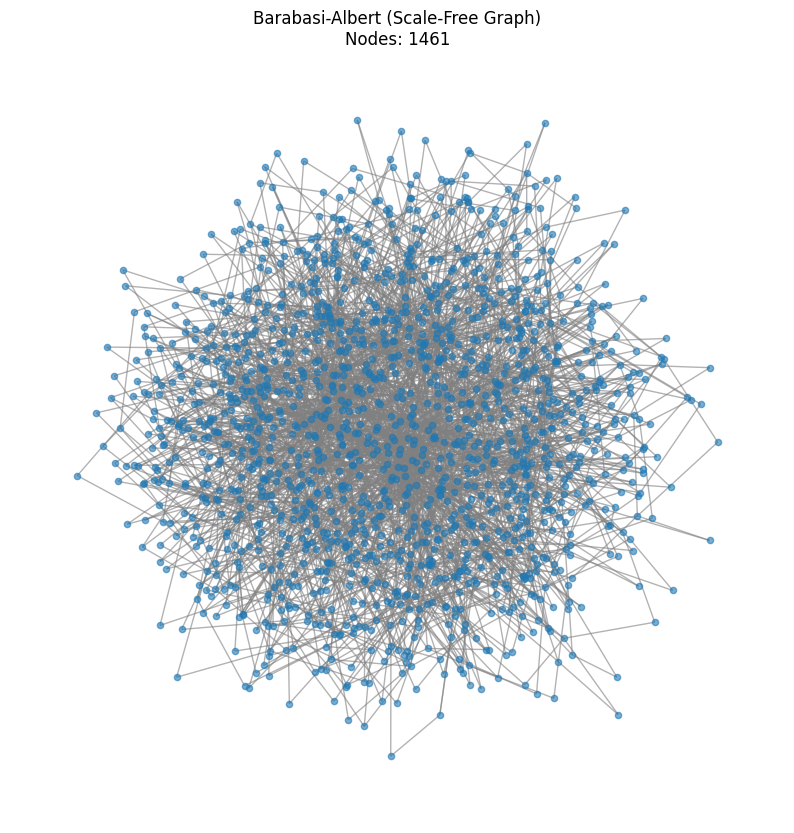

In [9]:
for name, net_data in network_cache.items():
    G = net_data['G']
    n = G.number_of_nodes()

    fig, ax = plt.subplots(figsize=(10, 10)) 

    pos = nx.spring_layout(G, seed=42)

    nx.draw(
        G,
        pos=pos,
        ax=ax,
        node_size=20,
        alpha=0.6,
        edge_color="gray"
    )

    ax.set_title(f"{name}\nNodes: {n}", fontsize=12)
    ax.set_axis_off()

    plt.show()
    plt.close()

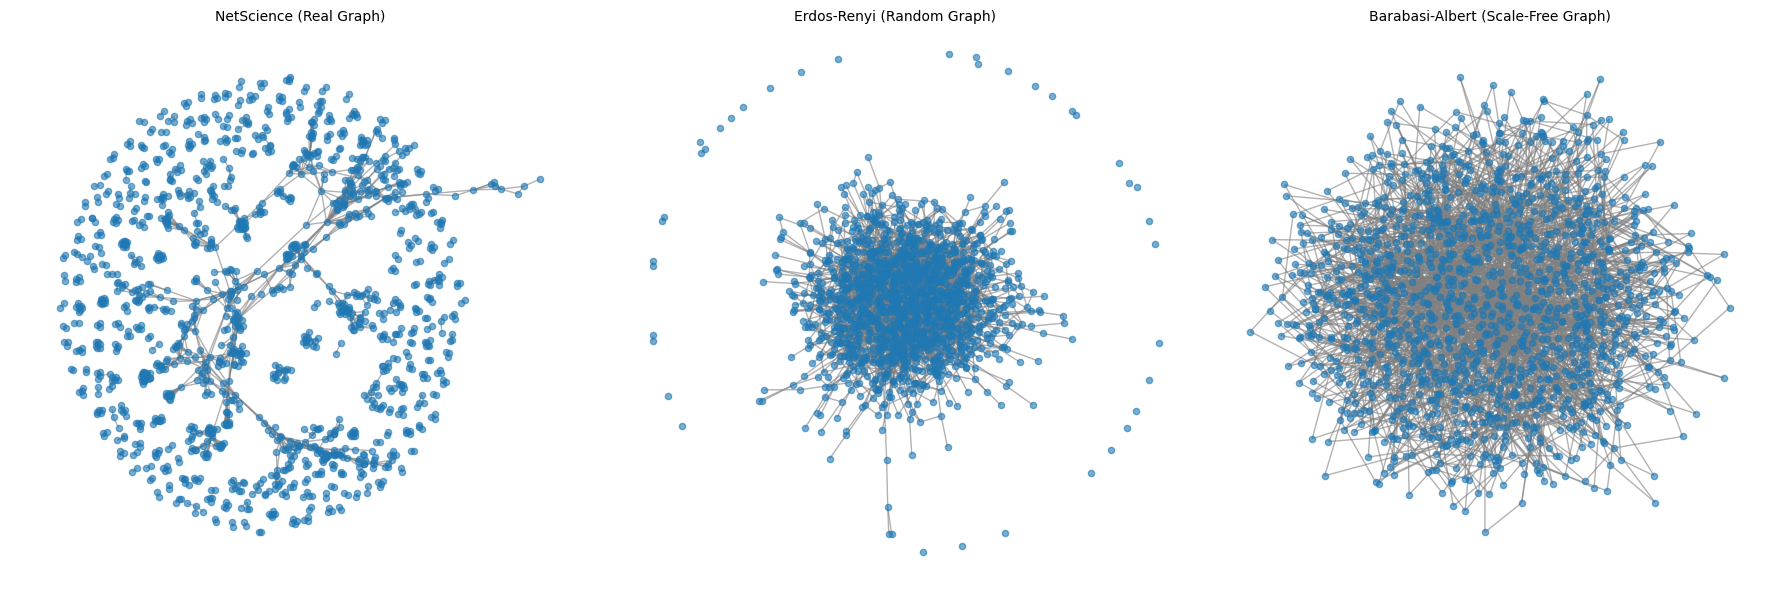

In [14]:
# Task 3: Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, net_data) in zip(axes, network_cache.items()):
    G = net_data['G']
    n = G.number_of_nodes()
    
    if n > 100000: # We sample the nodes to visualize cleanly
        highest_deg_node = max(dict(G.degree()).items(), key=lambda x: x[1])[0]
        nodes_to_draw = set([highest_deg_node])
        for n_adj in G.neighbors(highest_deg_node):
            nodes_to_draw.add(n_adj)
            if len(nodes_to_draw) > 150: break
        G_draw = G.subgraph(nodes_to_draw)
        title = f"{name}\n(Sampled around max degree)"
    else:
        G_draw = G
        title = name
        
    pos = nx.spring_layout(G_draw, seed=42)
    nx.draw(G_draw, pos, ax=ax, node_size=20, alpha=0.6, edge_color="gray")
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

### 4. Distributions
Compute and plot: degree distribution, clustering coefficient distribution, betweenness centrality distribution, connected components size distribution.


--- NetScience (Real Graph) Distributions ---


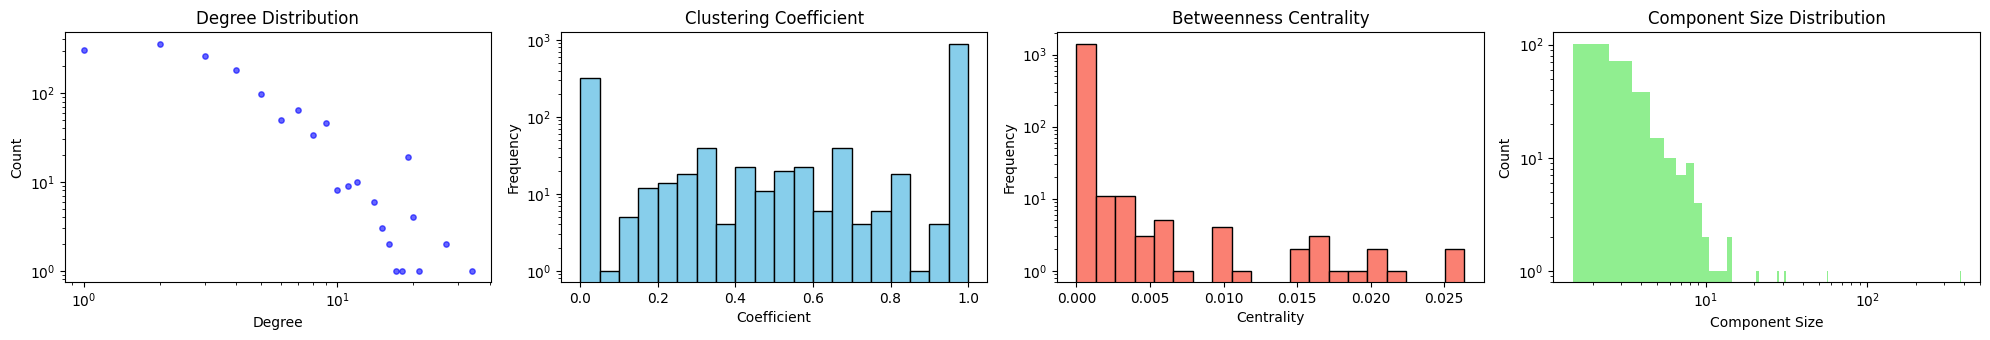


--- Erdos-Renyi (Random Graph) Distributions ---


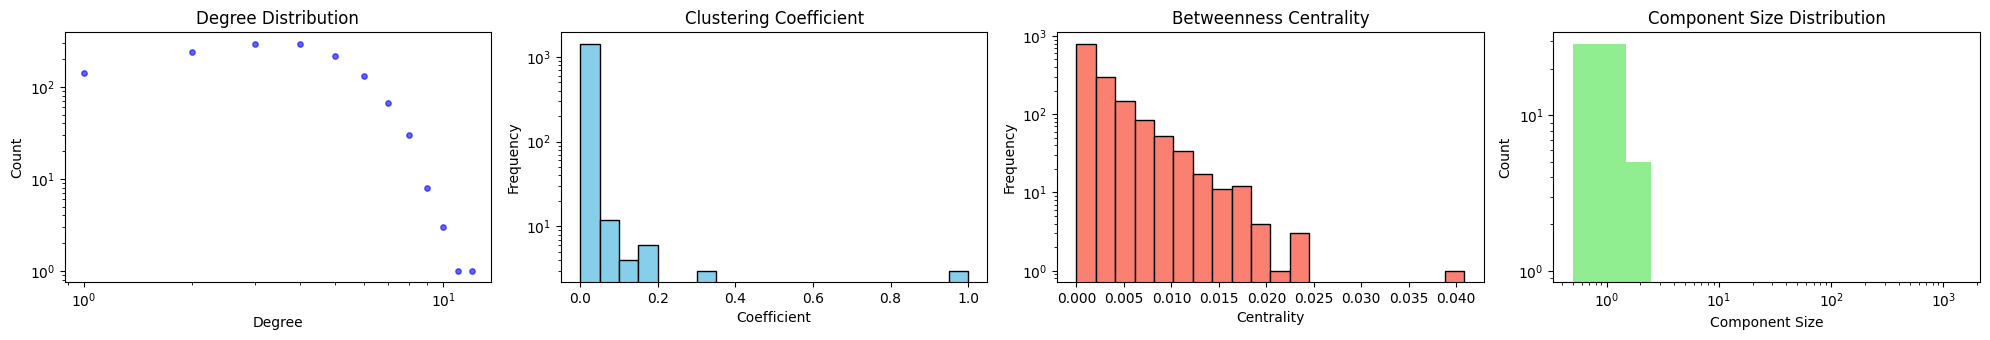


--- Barabasi-Albert (Scale-Free Graph) Distributions ---


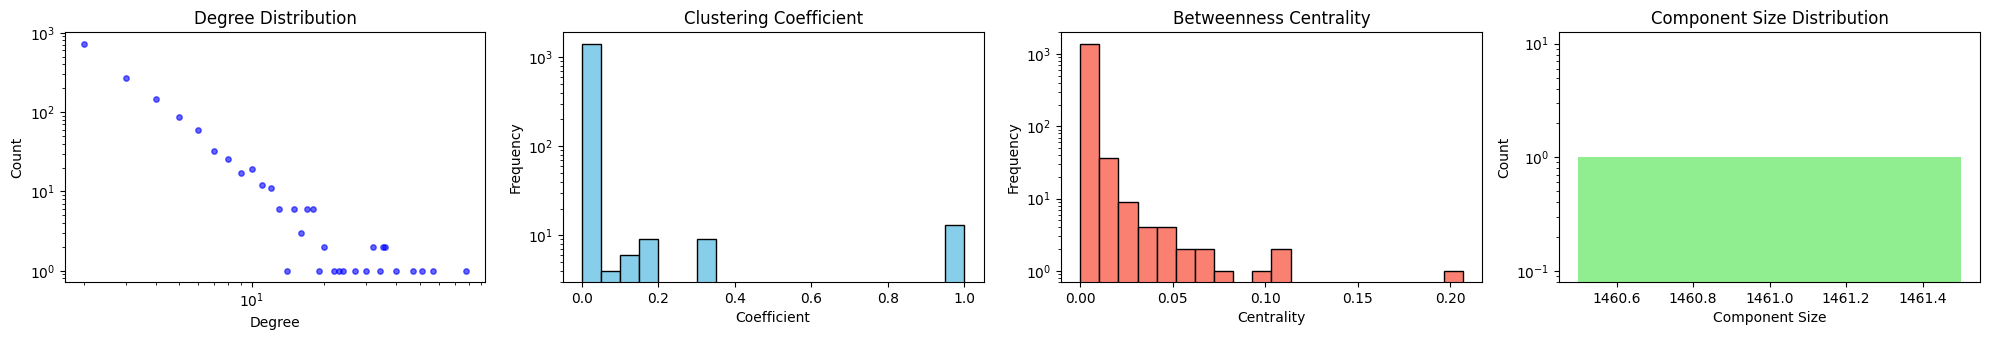

In [15]:
# Task 4: Distributions
for name, net_data in network_cache.items():
    G = net_data['G']
    ccs = net_data['ccs']
    
    print(f"\n--- {name} Distributions ---")
    fig, axes = plt.subplots(1, 4, figsize=(20, 3.5))
    
    # 4.1 Degree Distribution
    deg_counts = Counter(dict(G.degree()).values())
    x_deg, y_deg = zip(*deg_counts.items())
    axes[0].scatter(x_deg, y_deg, alpha=0.6, s=15, color='blue')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_title("Degree Distribution")
    axes[0].set_xlabel("Degree")
    axes[0].set_ylabel("Count")
    
    # 4.2 Clustering Coefficient Distribution
    clustering_dict = nx.clustering(G)
    axes[1].hist(list(clustering_dict.values()), bins=20, color='skyblue', edgecolor='black')
    axes[1].set_title("Clustering Coefficient")
    axes[1].set_xlabel("Coefficient")
    axes[1].set_ylabel("Frequency")
    axes[1].set_yscale('log')
    
    # 4.3 Betweenness Centrality Distribution
    # Calculate betweenness centrality (sampled if graph is large to save time)
    n = G.number_of_nodes()
    # Cache the betweenness to reuse in task 5
    bet_cent = nx.betweenness_centrality(G, k=100 if n>500 else None)
    network_cache[name]['bet_cent'] = bet_cent  # We cache this to reuse!
    
    axes[2].hist(list(bet_cent.values()), bins=20, color='salmon', edgecolor='black')
    axes[2].set_title("Betweenness Centrality")
    axes[2].set_xlabel("Centrality")
    axes[2].set_ylabel("Frequency")
    axes[2].set_yscale('log')
    
    # 4.4 Connected Components Size Distribution
    cc_sizes = [len(c) for c in ccs]
    size_counts = Counter(cc_sizes)
    axes[3].bar(size_counts.keys(), size_counts.values(), width=1.0, color='lightgreen')
    axes[3].set_yscale('log')
    if len(size_counts) > 1:
        axes[3].set_xscale('log')
    axes[3].set_title("Component Size Distribution")
    axes[3].set_xlabel("Component Size")
    axes[3].set_ylabel("Count")
    
    plt.tight_layout()
    plt.show()

### 5. Important Nodes
Identify most important nodes according to different measures (Degree and Betweenness Centrality)

In [12]:
# Task 5: Important Nodes
for name, net_data in network_cache.items():
    G = net_data['G']
    bet_cent = net_data.get('bet_cent', {})
    
    print(f"\n--- Highly Central Nodes in {name} ---")
    
    # By Degree
    sorted_deg = sorted(dict(G.degree()).items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"Top 5 by Degree:")
    for node, deg in sorted_deg:
        print(f"   Node {node}: {deg} edges")
        
    # By Betweenness Centrality
    if bet_cent:
        sorted_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:5]
        print(f"Top 5 by Betweenness Centrality:")
        for node, bc in sorted_bet:
            print(f"   Node {node}: {bc:.6f}")
    else:
        print("Run the previous cell to calculate Betweenness Centrality first.")


--- Highly Central Nodes in NetScience (Real Graph) ---
Top 5 by Degree:
   Node 44: 34 edges
   Node 45: 27 edges
   Node 107: 27 edges
   Node 46: 21 edges
   Node 532: 20 edges
Top 5 by Betweenness Centrality:
   Node 107: 0.030818
   Node 185: 0.026153
   Node 205: 0.019756
   Node 85: 0.019112
   Node 45: 0.018886

--- Highly Central Nodes in Erdos-Renyi (Random Graph) ---
Top 5 by Degree:
   Node 277: 12 edges
   Node 303: 11 edges
   Node 142: 10 edges
   Node 421: 10 edges
   Node 1406: 10 edges
Top 5 by Betweenness Centrality:
   Node 277: 0.028722
   Node 1405: 0.025110
   Node 142: 0.023858
   Node 360: 0.019562
   Node 1224: 0.018863

--- Highly Central Nodes in Barabasi-Albert (Scale-Free Graph) ---
Top 5 by Degree:
   Node 0: 78 edges
   Node 6: 57 edges
   Node 1: 51 edges
   Node 7: 47 edges
   Node 9: 40 edges
Top 5 by Betweenness Centrality:
   Node 0: 0.211285
   Node 6: 0.114431
   Node 7: 0.110018
   Node 1: 0.094500
   Node 9: 0.073506


### 6. What type of network is the selected real network?

The **dimacs10-netscience** dataset is an undirected network of co-authorships in the area of network science. 
*   **Significance & Meaning:** Nodes represent authors (researchers), and links represent a co-authorship between them (they have written a paper together).
*   **Type of Network:** It is a **Co-authorship/Collaboration Network**. Because it reflects human collaboration and distinct research communities, it exhibits "small-world" properties (a high clustering coefficient, as co-authors of a researcher are very likely to co-author with each other) and "scale-free" characteristics (a heavy-tailed degree distribution where a few highly published researchers act as massive hubs). We can observe these hallmarks by comparing its structural metrics to the Erdős-Rényi and Barabási-Albert models.